# MODEL TRAINING - BASELINE COMPARISON
# Start here after EDA is complete

In [1]:
# CELL 1: IMPORTS AND SETUP
# This cell imports all necessary libraries for model training
# and sets up the environment.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, roc_curve
)

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# CELL 2: LOAD THE FEATURE-ENGINEERED DATASET
# This cell loads the dataset you created during EDA.
# It's the final training-ready dataset with 62 columns.

print("LOADING DATASET")
# Load the feature-engineered dataset
df = pd.read_csv('output/feature_engineered_dataset.csv', low_memory=False)

print(f"Dataset loaded successfully!")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Check label distributions
print("\nLabel Distributions:")
for label in ['label_growth_opportunity', 'label_risk_signal', 'label_lending_need_proxy']:
    pos = df[label].sum()
    neg = len(df) - pos
    ratio = neg / pos if pos > 0 else 0
    print(f"   {label}:")
    print(f"      Positive: {pos:,} ({pos/len(df)*100:.1f}%)")
    print(f"      Negative: {neg:,} ({neg/len(df)*100:.1f}%)")
    print(f"      Ratio: {ratio:.1f}:1")

LOADING DATASET


Dataset loaded successfully!
   Rows: 3,145,434
   Columns: 45

Label Distributions:
   label_growth_opportunity:
      Positive: 1,782,383 (56.7%)
      Negative: 1,363,051 (43.3%)
      Ratio: 0.8:1
   label_risk_signal:
      Positive: 207,014 (6.6%)
      Negative: 2,938,420 (93.4%)
      Ratio: 14.2:1
   label_lending_need_proxy:
      Positive: 405,783 (12.9%)
      Negative: 2,739,651 (87.1%)
      Ratio: 6.8:1


In [3]:
# CELL 3: DEFINE LEAKAGE-SAFE FEATURE LISTS
# These feature lists are from your EDA notebook.
# Each label has specific columns excluded to prevent data leakage.
# For example, Growth excludes age-related columns because age was
# used to build the growth label.

print("DEFINING FEATURE LISTS")

# GROWTH FEATURES
# Excludes: company_age_years, is_active, is_dormant, accounts_overdue_days
# Reason: These were used to build the growth label
GROWTH_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate', 'mortgage_active_ratio',
    'mortgage_per_year', 'company_size_score', 'age_vs_sector_avg',
    'is_severely_overdue', 'overdue_intensity',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate', 
    'sector_dormant_rate', 'sic_division',
    'active_with_mortgages', 'small_and_growing', 'overdue_and_active',
    'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total', 'has_active_mortgages',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'accounts_ever_late', 'conf_stmt_overdue_days',
    'total_overdue_days', 'log_overdue'
]
# Keep only features that exist in the dataset
GROWTH_FEATURES = [c for c in GROWTH_FEATURES if c in df.columns]

# RISK FEATURES
# Excludes: accounts_ever_late, conf_stmt_overdue_days, total_overdue_days
# Reason: These were used to build the risk label
RISK_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate', 'mortgage_active_ratio',
    'mortgage_per_year', 'company_size_score', 'log_company_age', 'age_bucket',
    'is_established', 'overdue_intensity', 'is_severely_overdue', 'log_overdue',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate',
    'sector_dormant_rate', 'age_vs_sector_avg', 'sic_division',
    'active_with_mortgages', 'small_and_growing', 'overdue_and_active',
    'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total', 'has_active_mortgages',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'company_age_years', 'is_active', 'is_dormant', 'accounts_overdue_days'
]
RISK_FEATURES = [c for c in RISK_FEATURES if c in df.columns]

# LENDING FEATURES
# Excludes: has_active_mortgages, active_with_mortgages, mortgage_active_ratio
# Reason: These were used to build the lending label
LENDING_FEATURES = [
    'has_mortgage_history', 'mortgage_completion_rate',
    'mortgage_per_year', 'company_size_score', 'log_company_age', 'age_bucket',
    'is_established', 'total_overdue_days', 'overdue_intensity',
    'is_severely_overdue', 'log_overdue',
    'sector_avg_age', 'sector_mortgage_rate', 'sector_overdue_rate',
    'sector_dormant_rate', 'age_vs_sector_avg', 'sic_division',
    'small_and_growing', 'overdue_and_active', 'full_accounts_with_charges',
    'is_micro', 'is_small', 'is_full_accounts', 'has_changed_name',
    'num_mortgages_outstanding', 'num_mortgages_total',
    'fast_growth_proxy',
    'Mortgages.NumMortCharges', 'Mortgages.NumMortSatisfied',
    'Mortgages.NumMortPartSatisfied',
    'company_age_years', 'is_active', 'is_dormant',
    'accounts_overdue_days', 'accounts_ever_late', 'conf_stmt_overdue_days'
]
LENDING_FEATURES = [c for c in LENDING_FEATURES if c in df.columns]

print(f" Feature lists defined:")
print(f"   Growth features:  {len(GROWTH_FEATURES)}")
print(f"   Risk features:    {len(RISK_FEATURES)}")
print(f"   Lending features: {len(LENDING_FEATURES)}")

DEFINING FEATURE LISTS
 Feature lists defined:
   Growth features:  32
   Risk features:    36
   Lending features: 36


In [4]:
# CELL 4: HELPER FUNCTIONS
# This cell contains utility functions used throughout training:
# 1. calculate_metrics() - Evaluates model performance
# 2. prepare_data() - Creates train/test splits with scaling

print("DEFINING HELPER FUNCTIONS")

def calculate_metrics(y_true, y_pred, y_prob):
    """
    Calculate all evaluation metrics for a model.
    
    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - y_prob: Predicted probabilities
    
    Returns:
    - Dictionary with all metrics
    """
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'avg_precision': average_precision_score(y_true, y_prob),
        'brier_score': brier_score_loss(y_true, y_prob)
    }


def prepare_data(df, target_col, feature_list, sample_size=100000):
    """
    Prepare data for model training.
    
    Parameters:
    - df: Full dataframe
    - target_col: Name of the target label column
    - feature_list: List of features to use
    - sample_size: Number of rows to sample (None for full dataset)
    
    Returns:
    - X_train, X_test, y_train, y_test, scaler
    """
    # Sample if requested
    if sample_size is not None and sample_size < len(df):
        df_sample = df.sample(n=sample_size, random_state=42)
        print(f"  Using sample: {sample_size:,} companies ({sample_size/len(df)*100:.1f}%)")
    else:
        df_sample = df
        print(f"  Using full dataset: {len(df_sample):,} companies")
    
    # Prepare features and target
    X = df_sample[feature_list].fillna(0).copy()
    y = df_sample[target_col].copy()
    
    # Scale features for Logistic Regression
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Train/test split with stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"  Training set: {len(X_train):,} samples")
    print(f"  Test set: {len(X_test):,} samples")
    
    return X_train, X_test, y_train, y_test, scaler

print(" Helper functions defined!")

DEFINING HELPER FUNCTIONS
 Helper functions defined!


In [5]:
print("="*70)
print("TRAINING: Growth Opportunity (Balanced)")
print("="*70)

print("\nPreparing data...")
X_train, X_test, y_train, y_test, scaler_growth = prepare_data(
    df, 'label_growth_opportunity', GROWTH_FEATURES, sample_size=100000
)
y_test_growth = y_test  # store for evaluation cells

print("\n[1/3] Training Logistic Regression...")
log_reg_growth = LogisticRegression(max_iter=1000, random_state=42)
log_reg_growth.fit(X_train, y_train)
y_pred_growth_lr = log_reg_growth.predict(X_test)
y_prob_growth_lr = log_reg_growth.predict_proba(X_test)[:, 1]
metrics_growth_lr = calculate_metrics(y_test, y_pred_growth_lr, y_prob_growth_lr)
print(f"   F1: {metrics_growth_lr['f1']:.4f}  |  ROC-AUC: {metrics_growth_lr['roc_auc']:.4f}")

print("\n[2/3] Training Random Forest...")
rf_growth = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_growth.fit(X_train, y_train)
y_pred_growth_rf = rf_growth.predict(X_test)
y_prob_growth_rf = rf_growth.predict_proba(X_test)[:, 1]
metrics_growth_rf = calculate_metrics(y_test, y_pred_growth_rf, y_prob_growth_rf)
print(f"   F1: {metrics_growth_rf['f1']:.4f}  |  ROC-AUC: {metrics_growth_rf['roc_auc']:.4f}")

print("\n[3/3] Training XGBoost...")
xgb_growth = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=1.0,
    random_state=42, eval_metric='logloss', use_label_encoder=False, verbosity=0
)
xgb_growth.fit(X_train, y_train)
y_pred_growth_xgb = xgb_growth.predict(X_test)
y_prob_growth_xgb = xgb_growth.predict_proba(X_test)[:, 1]
metrics_growth_xgb = calculate_metrics(y_test, y_pred_growth_xgb, y_prob_growth_xgb)
print(f"   F1: {metrics_growth_xgb['f1']:.4f}  |  ROC-AUC: {metrics_growth_xgb['roc_auc']:.4f}")

growth_results = {
    'Logistic Regression': metrics_growth_lr,
    'Random Forest':        metrics_growth_rf,
    'XGBoost':              metrics_growth_xgb
}
growth_predictions = {
    'Logistic Regression': {'y_pred': y_pred_growth_lr, 'y_prob': y_prob_growth_lr},
    'Random Forest':        {'y_pred': y_pred_growth_rf, 'y_prob': y_prob_growth_rf},
    'XGBoost':              {'y_pred': y_pred_growth_xgb, 'y_prob': y_prob_growth_xgb}
}
growth_models = {
    'Logistic Regression': log_reg_growth,
    'Random Forest': rf_growth,
    'XGBoost': xgb_growth
}
print("\nGrowth models trained successfully!")

TRAINING: Growth Opportunity (Balanced)

Preparing data...
  Using sample: 100,000 companies (3.2%)


  Training set: 80,000 samples
  Test set: 20,000 samples

[1/3] Training Logistic Regression...


   F1: 0.9064  |  ROC-AUC: 0.9517

[2/3] Training Random Forest...


   F1: 0.9304  |  ROC-AUC: 0.9688

[3/3] Training XGBoost...


   F1: 0.9341  |  ROC-AUC: 0.9767

Growth models trained successfully!


In [6]:
print("TRAINING: Risk Signal (Imbalanced - 14:1)")

print("\nPreparing data...")
X_train, X_test, y_train, y_test, scaler_risk = prepare_data(
    df, 'label_risk_signal', RISK_FEATURES, sample_size=100000
)
y_test_risk = y_test  # store for evaluation cells

neg_risk = (y_train == 0).sum()
pos_risk = (y_train == 1).sum()
risk_weight = neg_risk / pos_risk if pos_risk > 0 else 1.0
print(f"   Class weight: {risk_weight:.1f}")

print("\n[1/3] Training Logistic Regression...")
log_reg_risk = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_risk.fit(X_train, y_train)
y_pred_risk_lr = log_reg_risk.predict(X_test)
y_prob_risk_lr = log_reg_risk.predict_proba(X_test)[:, 1]
metrics_risk_lr = calculate_metrics(y_test, y_pred_risk_lr, y_prob_risk_lr)
print(f"   F1: {metrics_risk_lr['f1']:.4f}  |  ROC-AUC: {metrics_risk_lr['roc_auc']:.4f}")

print("\n[2/3] Training Random Forest...")
rf_risk = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_risk.fit(X_train, y_train)
y_pred_risk_rf = rf_risk.predict(X_test)
y_prob_risk_rf = rf_risk.predict_proba(X_test)[:, 1]
metrics_risk_rf = calculate_metrics(y_test, y_pred_risk_rf, y_prob_risk_rf)
print(f"   F1: {metrics_risk_rf['f1']:.4f}  |  ROC-AUC: {metrics_risk_rf['roc_auc']:.4f}")

print("\n[3/3] Training XGBoost...")
xgb_risk = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=risk_weight,
    random_state=42, eval_metric='logloss', use_label_encoder=False, verbosity=0
)
xgb_risk.fit(X_train, y_train)
y_pred_risk_xgb = xgb_risk.predict(X_test)
y_prob_risk_xgb = xgb_risk.predict_proba(X_test)[:, 1]
metrics_risk_xgb = calculate_metrics(y_test, y_pred_risk_xgb, y_prob_risk_xgb)
print(f"   F1: {metrics_risk_xgb['f1']:.4f}  |  ROC-AUC: {metrics_risk_xgb['roc_auc']:.4f}")

risk_results = {
    'Logistic Regression': metrics_risk_lr,
    'Random Forest':        metrics_risk_rf,
    'XGBoost':              metrics_risk_xgb
}
risk_predictions = {
    'Logistic Regression': {'y_pred': y_pred_risk_lr, 'y_prob': y_prob_risk_lr},
    'Random Forest':        {'y_pred': y_pred_risk_rf, 'y_prob': y_prob_risk_rf},
    'XGBoost':              {'y_pred': y_pred_risk_xgb, 'y_prob': y_prob_risk_xgb}
}
risk_models = {
    'Logistic Regression': log_reg_risk,
    'Random Forest': rf_risk,
    'XGBoost': xgb_risk
}
print("\nRisk models trained successfully!")

TRAINING: Risk Signal (Imbalanced - 14:1)

Preparing data...
  Using sample: 100,000 companies (3.2%)


  Training set: 80,000 samples
  Test set: 20,000 samples
   Class weight: 14.3

[1/3] Training Logistic Regression...


   F1: 0.9652  |  ROC-AUC: 0.9993

[2/3] Training Random Forest...


   F1: 0.9852  |  ROC-AUC: 1.0000

[3/3] Training XGBoost...


   F1: 0.9973  |  ROC-AUC: 1.0000

Risk models trained successfully!


In [7]:
print("TRAINING: Lending Need Proxy (Imbalanced - 7:1)")

print("\nPreparing data...")
X_train, X_test, y_train, y_test, scaler_lending = prepare_data(
    df, 'label_lending_need_proxy', LENDING_FEATURES, sample_size=100000
)
y_test_lending = y_test  # store for evaluation cells

neg_lending = (y_train == 0).sum()
pos_lending = (y_train == 1).sum()
lending_weight = neg_lending / pos_lending if pos_lending > 0 else 1.0
print(f"   Class weight: {lending_weight:.1f}")

print("\n[1/3] Training Logistic Regression...")
log_reg_lending = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg_lending.fit(X_train, y_train)
y_pred_lending_lr = log_reg_lending.predict(X_test)
y_prob_lending_lr = log_reg_lending.predict_proba(X_test)[:, 1]
metrics_lending_lr = calculate_metrics(y_test, y_pred_lending_lr, y_prob_lending_lr)
print(f"   F1: {metrics_lending_lr['f1']:.4f}  |  ROC-AUC: {metrics_lending_lr['roc_auc']:.4f}")

print("\n[2/3] Training Random Forest...")
rf_lending = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_lending.fit(X_train, y_train)
y_pred_lending_rf = rf_lending.predict(X_test)
y_prob_lending_rf = rf_lending.predict_proba(X_test)[:, 1]
metrics_lending_rf = calculate_metrics(y_test, y_pred_lending_rf, y_prob_lending_rf)
print(f"   F1: {metrics_lending_rf['f1']:.4f}  |  ROC-AUC: {metrics_lending_rf['roc_auc']:.4f}")

print("\n[3/3] Training XGBoost...")
xgb_lending = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=lending_weight,
    random_state=42, eval_metric='logloss', use_label_encoder=False, verbosity=0
)
xgb_lending.fit(X_train, y_train)
y_pred_lending_xgb = xgb_lending.predict(X_test)
y_prob_lending_xgb = xgb_lending.predict_proba(X_test)[:, 1]
metrics_lending_xgb = calculate_metrics(y_test, y_pred_lending_xgb, y_prob_lending_xgb)
print(f"   F1: {metrics_lending_xgb['f1']:.4f}  |  ROC-AUC: {metrics_lending_xgb['roc_auc']:.4f}")

lending_results = {
    'Logistic Regression': metrics_lending_lr,
    'Random Forest':        metrics_lending_rf,
    'XGBoost':              metrics_lending_xgb
}
lending_predictions = {
    'Logistic Regression': {'y_pred': y_pred_lending_lr, 'y_prob': y_prob_lending_lr},
    'Random Forest':        {'y_pred': y_pred_lending_rf, 'y_prob': y_prob_lending_rf},
    'XGBoost':              {'y_pred': y_pred_lending_xgb, 'y_prob': y_prob_lending_xgb}
}
lending_models = {
    'Logistic Regression': log_reg_lending,
    'Random Forest': rf_lending,
    'XGBoost': xgb_lending
}
print("\nLending models trained successfully!")

TRAINING: Lending Need Proxy (Imbalanced - 7:1)

Preparing data...
  Using sample: 100,000 companies (3.2%)


  Training set: 80,000 samples
  Test set: 20,000 samples
   Class weight: 6.7

[1/3] Training Logistic Regression...
   F1: 0.9971  |  ROC-AUC: 0.9999

[2/3] Training Random Forest...


   F1: 1.0000  |  ROC-AUC: 1.0000

[3/3] Training XGBoost...


   F1: 1.0000  |  ROC-AUC: 1.0000

Lending models trained successfully!


In [8]:
# CELL 8: COMBINE ALL RESULTS
# This cell combines results from all three labels into
# a single summary table for easy comparison.

print("COMBINING ALL RESULTS")

# Combine all results
all_results = {
    'growth': growth_results,
    'risk': risk_results,
    'lending': lending_results
}

# Create summary dataframe
summary_data = []
for label in ['growth', 'risk', 'lending']:
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    
    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        row = all_results[label][model].copy()
        row['Label'] = label_name
        row['Model'] = model
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[['Label', 'Model', 'accuracy', 'precision', 'recall', 
                         'f1', 'roc_auc', 'avg_precision', 'brier_score']]
summary_df = summary_df.round(4)

print("\n COMPLETE RESULTS SUMMARY:")
print(summary_df.to_string(index=False))

# Save results
summary_df.to_csv('output/baseline_results_summary.csv', index=False)
print("\n Saved: output/baseline_results_summary.csv")

COMBINING ALL RESULTS

 COMPLETE RESULTS SUMMARY:
             Label               Model  accuracy  precision  recall     f1  roc_auc  avg_precision  brier_score
Growth Opportunity Logistic Regression    0.8917     0.8826  0.9315 0.9064   0.9517         0.9524       0.0819
Growth Opportunity       Random Forest    0.9164     0.8750  0.9933 0.9304   0.9688         0.9675       0.0664
Growth Opportunity             XGBoost    0.9217     0.8883  0.9847 0.9341   0.9767         0.9779       0.0534
       Risk Signal Logistic Regression    0.9953     0.9387  0.9931 0.9652   0.9993         0.9981       0.0039
       Risk Signal       Random Forest    0.9980     0.9775  0.9931 0.9852   1.0000         0.9995       0.0021
       Risk Signal             XGBoost    0.9996     0.9962  0.9985 0.9973   1.0000         1.0000       0.0003
Lending Need Proxy Logistic Regression    0.9992     0.9950  0.9992 0.9971   0.9999         0.9992       0.0008
Lending Need Proxy       Random Forest    1.0000     1

In [9]:
# CELL 9: FIND BEST MODEL PER LABEL
# This cell identifies the best model for each label based on:
# - F1 Score (primary - balances precision and recall)
# - ROC-AUC (discriminative ability)
# - Brier Score (calibration quality)

print("BEST MODEL PER LABEL")

best_models = {}

for label in ['growth', 'risk', 'lending']:
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    
    print(f"\n {label_name}:")
    print("-"*50)
    
    # Best by F1 (primary for imbalanced)
    best_f1 = max(all_results[label].items(), key=lambda x: x[1]['f1'])
    print(f"   Best F1: {best_f1[0]} ({best_f1[1]['f1']:.4f})")
    
    # Best by ROC-AUC
    best_auc = max(all_results[label].items(), key=lambda x: x[1]['roc_auc'])
    print(f"   Best AUC: {best_auc[0]} ({best_auc[1]['roc_auc']:.4f})")
    
    # Best calibration (lowest brier)
    best_cal = min(all_results[label].items(), key=lambda x: x[1]['brier_score'])
    print(f"   Best Calibration: {best_cal[0]} (Brier: {best_cal[1]['brier_score']:.4f})")
    
    # Recommendation
    recommended = best_f1[0]
    print(f"\n   ✅ RECOMMENDED: {recommended}")
    best_models[label] = recommended

print("SUMMARY OF RECOMMENDED MODELS:")
for label, model in best_models.items():
    label_name = {
        'growth': 'Growth Opportunity',
        'risk': 'Risk Signal',
        'lending': 'Lending Need Proxy'
    }[label]
    print(f"   {label_name}: {model}")

# Save recommendations
best_df = pd.DataFrame([
    {'Label': 'Growth Opportunity', 'Recommended Model': best_models['growth']},
    {'Label': 'Risk Signal', 'Recommended Model': best_models['risk']},
    {'Label': 'Lending Need Proxy', 'Recommended Model': best_models['lending']}
])
best_df.to_csv('output/recommended_models.csv', index=False)
print("\n Saved: output/recommended_models.csv")

BEST MODEL PER LABEL

 Growth Opportunity:
--------------------------------------------------
   Best F1: XGBoost (0.9341)
   Best AUC: XGBoost (0.9767)
   Best Calibration: XGBoost (Brier: 0.0534)

   ✅ RECOMMENDED: XGBoost

 Risk Signal:
--------------------------------------------------
   Best F1: XGBoost (0.9973)
   Best AUC: XGBoost (1.0000)
   Best Calibration: XGBoost (Brier: 0.0003)

   ✅ RECOMMENDED: XGBoost

 Lending Need Proxy:
--------------------------------------------------
   Best F1: Random Forest (1.0000)
   Best AUC: Random Forest (1.0000)
   Best Calibration: XGBoost (Brier: 0.0000)

   ✅ RECOMMENDED: Random Forest
SUMMARY OF RECOMMENDED MODELS:
   Growth Opportunity: XGBoost
   Risk Signal: XGBoost
   Lending Need Proxy: Random Forest

 Saved: output/recommended_models.csv


GENERATING PERFORMANCE VISUALIZATIONS


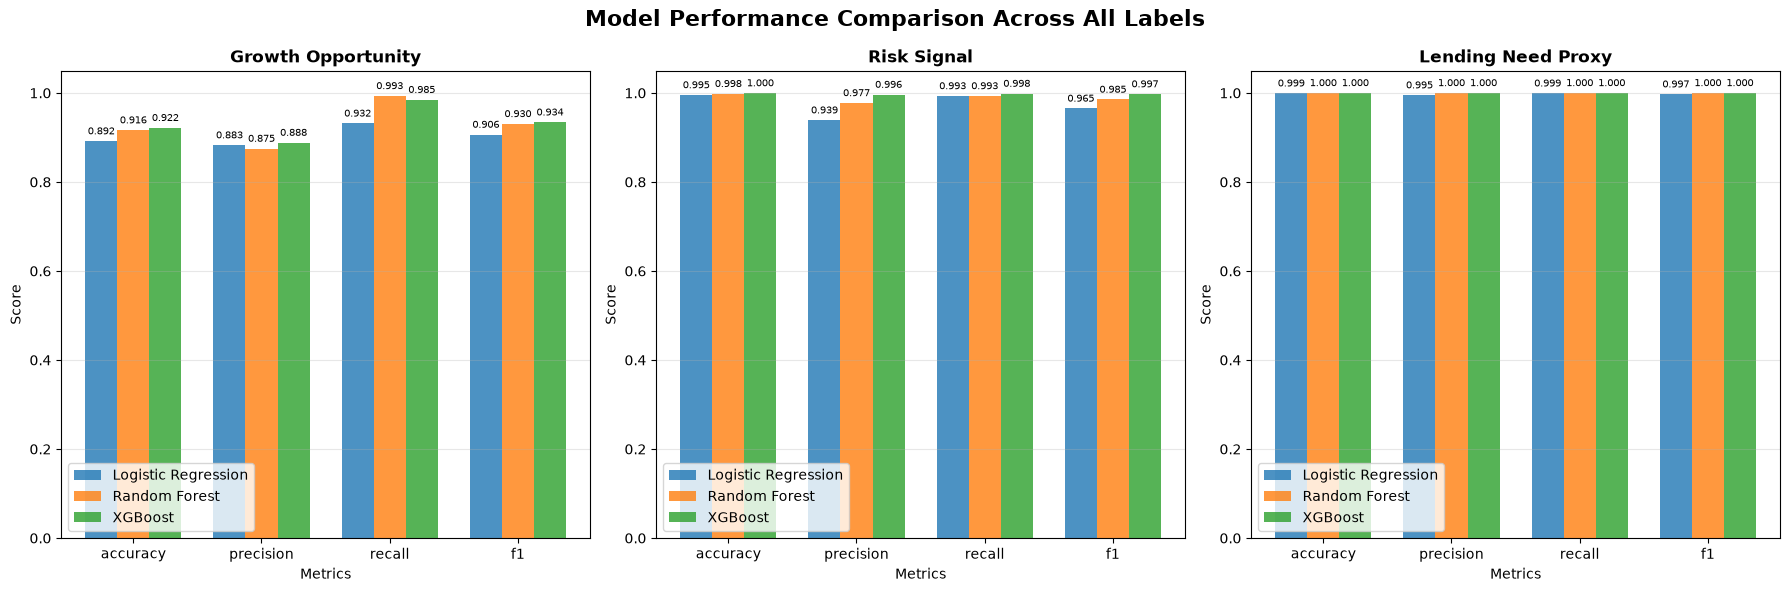

 Saved: output/baseline_performance_chart.png


In [10]:
# CELL 10: VISUALIZE PERFORMANCE COMPARISON
# This cell creates bar charts comparing all models
# across all labels for key metrics.

print("GENERATING PERFORMANCE VISUALIZATIONS")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison Across All Labels', 
             fontsize=16, fontweight='bold')

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = {
    'Logistic Regression': '#1f77b4',  # Blue
    'Random Forest': '#ff7f0e',        # Orange
    'XGBoost': '#2ca02c'               # Green
}

for idx, (label, title) in enumerate([
    ('growth', 'Growth Opportunity'),
    ('risk', 'Risk Signal'),
    ('lending', 'Lending Need Proxy')
]):
    ax = axes[idx]
    
    x = np.arange(len(metrics))
    width = 0.25
    
    for i, model in enumerate(['Logistic Regression', 'Random Forest', 'XGBoost']):
        scores = [all_results[label][model][m] for m in metrics]
        bars = ax.bar(x + (i-1)*width, scores, width, 
                     label=model, color=colors[model], alpha=0.8)
        
        # Add values on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=7)
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/baseline_performance_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Saved: output/baseline_performance_chart.png")

GENERATING ROC CURVES


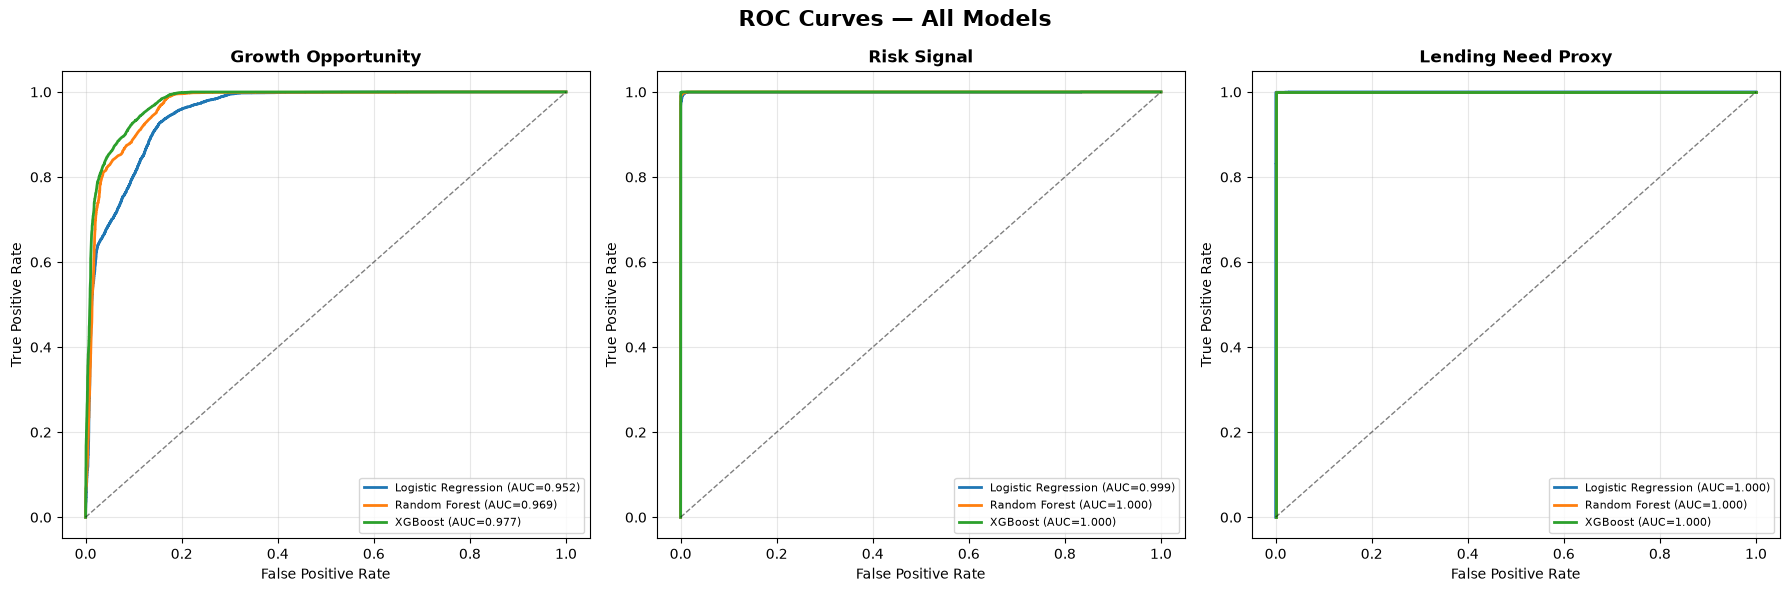

Saved: output/roc_curves.png


In [11]:
print("GENERATING ROC CURVES")

all_predictions = {
    'growth':  growth_predictions,
    'risk':    risk_predictions,
    'lending': lending_predictions
}

# Use the correct y_test per label (stored during each training cell)
y_tests_map = {
    'growth':  y_test_growth,
    'risk':    y_test_risk,
    'lending': y_test_lending
}

colors = {
    'Logistic Regression': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'XGBoost': '#2ca02c'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('ROC Curves — All Models', fontsize=16, fontweight='bold')

for idx, (label, title) in enumerate([
    ('growth',  'Growth Opportunity'),
    ('risk',    'Risk Signal'),
    ('lending', 'Lending Need Proxy')
]):
    ax = axes[idx]
    y_true = y_tests_map[label]

    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        y_prob = all_predictions[label][model]['y_prob']
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = all_results[label][model]['roc_auc']
        ax.plot(fpr, tpr, label=f'{model} (AUC={roc_auc:.3f})', color=colors[model], lw=2)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/roc_curves.png")

GENERATING PRECISION-RECALL CURVES
PR curves are more informative than ROC for imbalanced labels
Baseline = random classifier (horizontal line at positive class ratio)


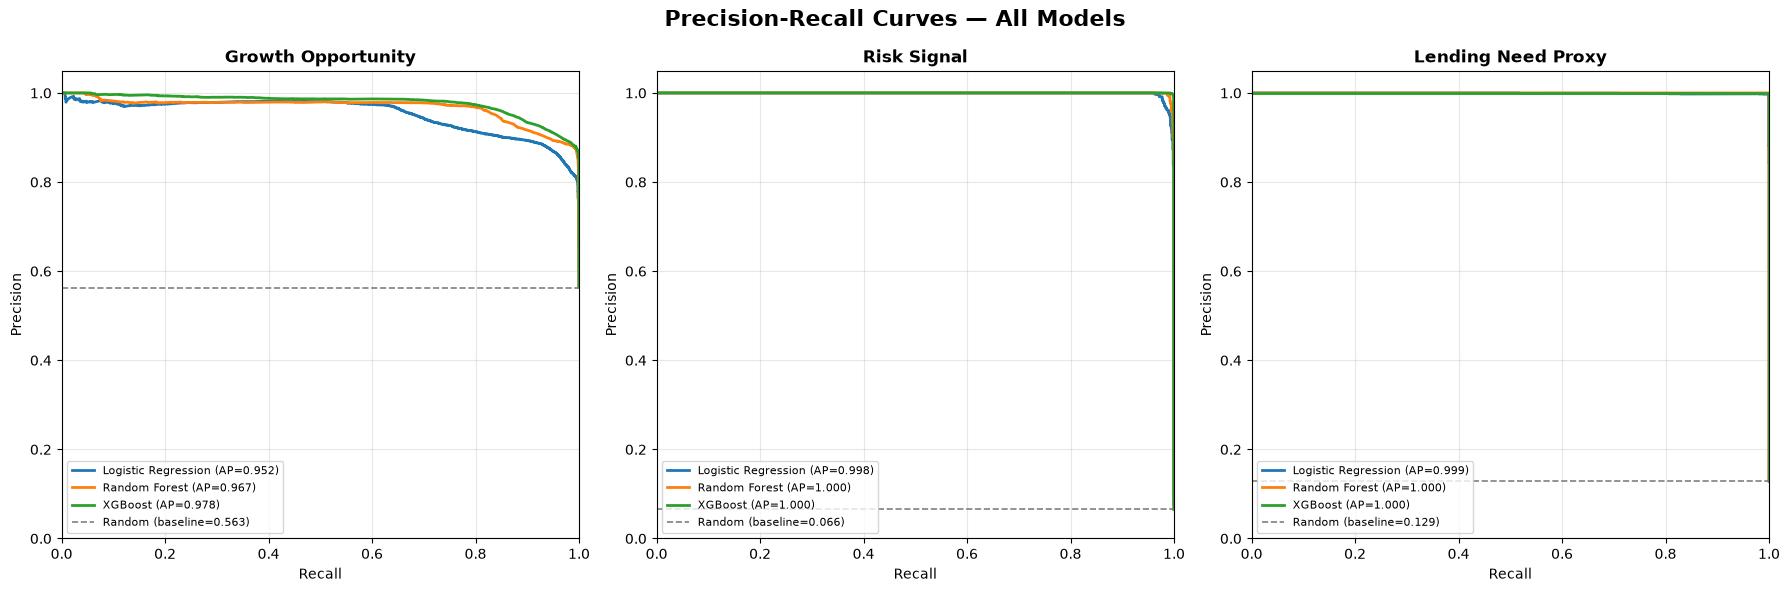

Saved: output/pr_curves.png
Saved: output/pr_auc_results.csv

Average Precision Summary (higher = better, baseline varies per label):
             Label               Model  Average_Precision
Growth Opportunity Logistic Regression             0.9524
Growth Opportunity       Random Forest             0.9675
Growth Opportunity             XGBoost             0.9779
       Risk Signal Logistic Regression             0.9981
       Risk Signal       Random Forest             0.9995
       Risk Signal             XGBoost             1.0000
Lending Need Proxy Logistic Regression             0.9992
Lending Need Proxy       Random Forest             1.0000
Lending Need Proxy             XGBoost             1.0000


In [12]:
from sklearn.metrics import precision_recall_curve

print("GENERATING PRECISION-RECALL CURVES")
print("PR curves are more informative than ROC for imbalanced labels")
print("Baseline = random classifier (horizontal line at positive class ratio)")

# Positive class ratio per label = baseline for a random classifier
baselines = {
    'growth':  y_test_growth.mean(),
    'risk':    y_test_risk.mean(),
    'lending': y_test_lending.mean(),
}

colors = {
    'Logistic Regression': '#1f77b4',
    'Random Forest': '#ff7f0e',
    'XGBoost': '#2ca02c'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Precision-Recall Curves — All Models', fontsize=16, fontweight='bold')

pr_rows = []

for idx, (label, title) in enumerate([
    ('growth',  'Growth Opportunity'),
    ('risk',    'Risk Signal'),
    ('lending', 'Lending Need Proxy'),
]):
    ax = axes[idx]
    y_true = y_tests_map[label]
    baseline = baselines[label]

    for model in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        y_prob = all_predictions[label][model]['y_prob']
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        ax.plot(recall, precision, label=f'{model} (AP={ap:.3f})', color=colors[model], lw=2)
        pr_rows.append({'Label': title, 'Model': model, 'Average_Precision': round(ap, 4)})

    # Baseline: random classifier
    ax.axhline(y=baseline, color='gray', linestyle='--', lw=1.2,
               label=f'Random (baseline={baseline:.3f})')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/pr_curves.png")

pd.DataFrame(pr_rows).to_csv('output/pr_auc_results.csv', index=False)
print("Saved: output/pr_auc_results.csv")

print("\nAverage Precision Summary (higher = better, baseline varies per label):")
print(pd.DataFrame(pr_rows).to_string(index=False))

In [13]:
# CELL 12: SAVE TRAINED MODELS
# This cell saves all trained models using joblib.
# You can load them later without retraining.

print("SAVING TRAINED MODELS")

import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save models with their scalers
model_data = {
    'growth': {
        'models': growth_models,
        'scaler': scaler_growth,
        'features': GROWTH_FEATURES,
        'results': growth_results
    },
    'risk': {
        'models': risk_models,
        'scaler': scaler_risk,
        'features': RISK_FEATURES,
        'results': risk_results
    },
    'lending': {
        'models': lending_models,
        'scaler': scaler_lending,
        'features': LENDING_FEATURES,
        'results': lending_results
    }
}

# Save each label's data
for label in ['growth', 'risk', 'lending']:
    joblib.dump(model_data[label], f'models/{label}_model_data.joblib')
    print(f"Saved: models/{label}_model_data.joblib")

print("\n Models saved successfully!")
print("To load: model_data = joblib.load('models/growth_model_data.joblib')")

SAVING TRAINED MODELS
Saved: models/growth_model_data.joblib
Saved: models/risk_model_data.joblib
Saved: models/lending_model_data.joblib

 Models saved successfully!
To load: model_data = joblib.load('models/growth_model_data.joblib')


In [14]:
print("GENERATING PREDICTIONS FOR ALL 3.1M COMPANIES")
print("Applying best model per label to full dataset...\n")

# Note: CompanyNumber/CompanyName were dropped from the training CSV to prevent leakage.
# Ranked output uses bcb_sector + sic_code_1 as identifiers.
id_cols = [c for c in ['bcb_sector', 'sic_code_1', 'sic_division'] if c in df.columns]
df_predictions = df[id_cols].copy()
df_predictions['row_index'] = df.index  # preserves original row order

label_config = {
    'growth':  {'model': growth_models[best_models['growth']],   'scaler': scaler_growth,  'features': GROWTH_FEATURES},
    'risk':    {'model': risk_models[best_models['risk']],       'scaler': scaler_risk,    'features': RISK_FEATURES},
    'lending': {'model': lending_models[best_models['lending']], 'scaler': scaler_lending, 'features': LENDING_FEATURES},
}

for label, config in label_config.items():
    print(f"Scoring {label}...")
    X = df[config['features']].fillna(0)
    X_scaled = config['scaler'].transform(X)
    df_predictions[f'{label}_prob']  = config['model'].predict_proba(X_scaled)[:, 1]
    df_predictions[f'{label}_label'] = config['model'].predict(X_scaled)

df_predictions = df_predictions.sort_values('growth_prob', ascending=False).reset_index(drop=True)
df_predictions.to_csv('output/predictions.csv', index=False)
print(f"\nSaved: output/predictions.csv  ({len(df_predictions):,} rows ranked by growth_prob)")

print(f"\nTop 10 by growth opportunity:")
print(df_predictions[['bcb_sector','sic_code_1','growth_prob','risk_prob','lending_prob']].head(10).to_string(index=False))

print(f"\nSector distribution of top 10,000 growth opportunities:")
print(df_predictions.head(10000)['bcb_sector'].value_counts().to_string())

GENERATING PREDICTIONS FOR ALL 3.1M COMPANIES
Applying best model per label to full dataset...

Scoring growth...


Scoring risk...


Scoring lending...



Saved: output/predictions.csv  (3,145,434 rows ranked by growth_prob)

Top 10 by growth opportunity:
 bcb_sector  sic_code_1  growth_prob  risk_prob  lending_prob
Real_Estate       68100     0.999254   0.000033      0.999855
Real_Estate       68209     0.999254   0.000033      0.999826
Real_Estate       68100     0.999254   0.000033      0.999855
Real_Estate       68209     0.999254   0.000033      0.999832
Real_Estate       68100     0.999254   0.000033      0.999663
Real_Estate       68100     0.999254   0.000033      0.999855
Real_Estate       68320     0.999254   0.000033      0.999855
Real_Estate       68100     0.999254   0.000033      0.999826
Real_Estate       68209     0.999254   0.000033      0.999826
Real_Estate       68100     0.999254   0.000033      0.999855

Sector distribution of top 10,000 growth opportunities:
bcb_sector
Real_Estate    10000


CONFUSION MATRICES — All Models × All Labels


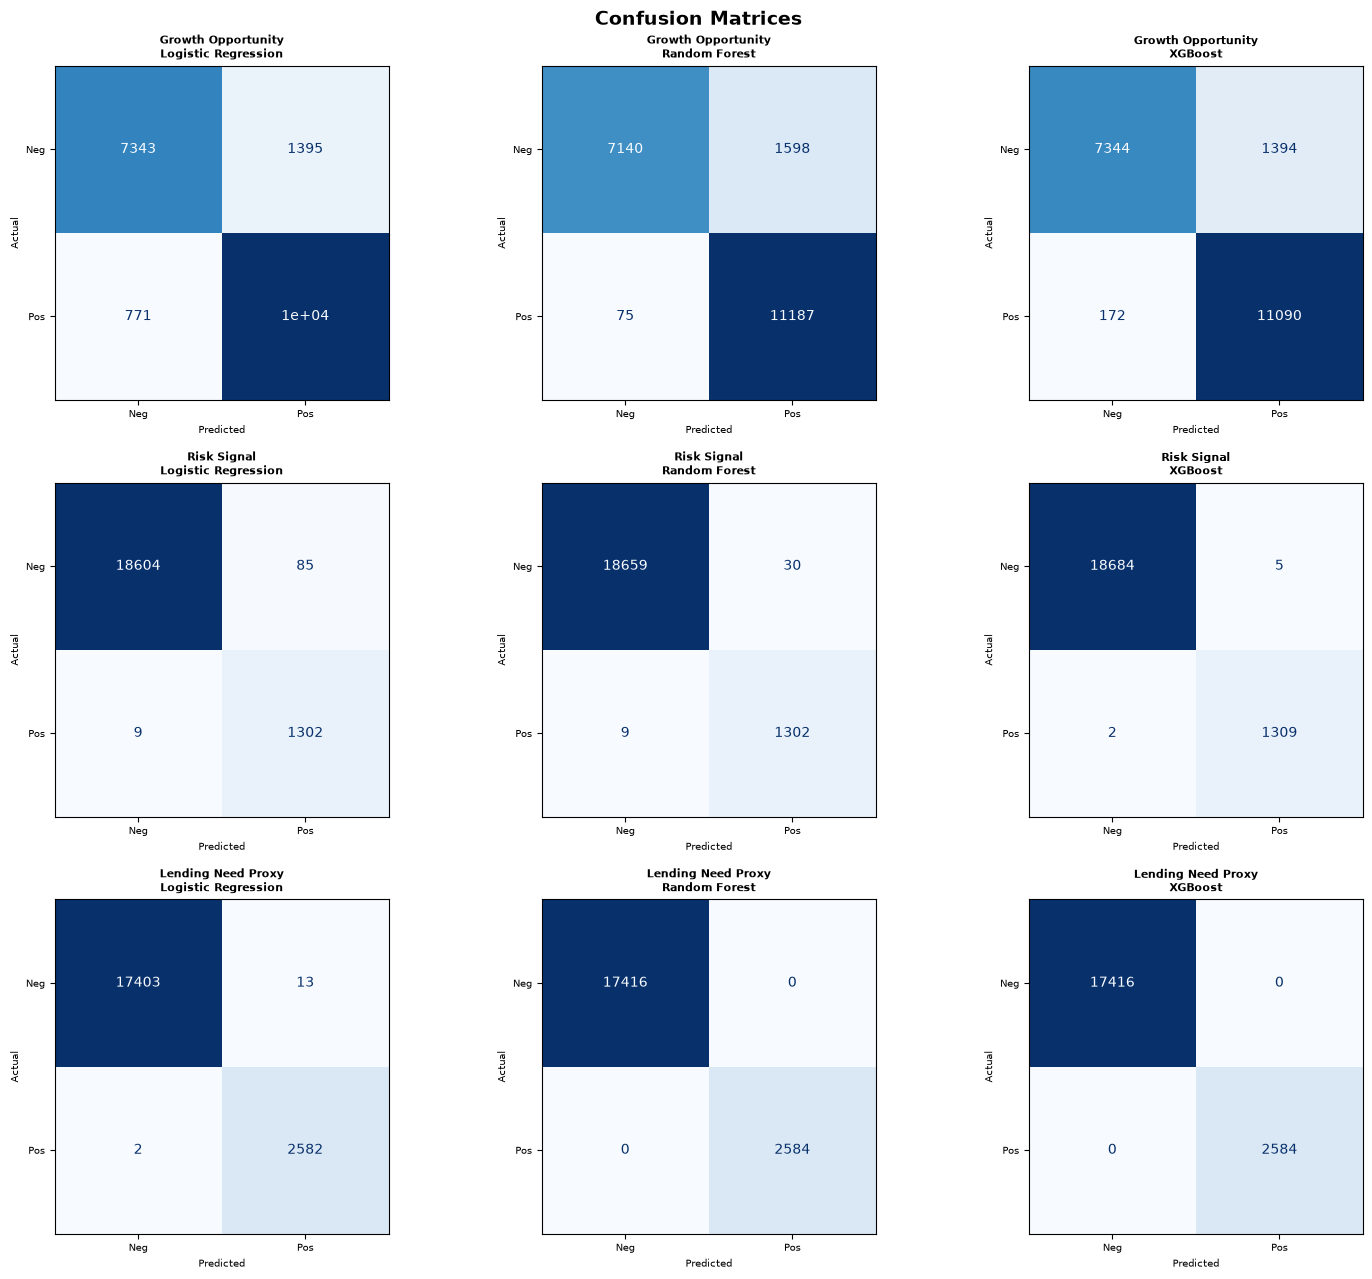

Saved: output/confusion_matrices.png

McNEMAR'S TEST — Pairwise Classifier Significance
H0: both classifiers make the same errors on the test set
p < 0.05 = significantly different  (* p<0.05  ** p<0.01  *** p<0.001  ns = not significant)

Growth:
   Logistic Regression    vs Random Forest           χ²=203.59  p=0.0000  ***
   Logistic Regression    vs XGBoost                 χ²=252.68  p=0.0000  ***
   Random Forest          vs XGBoost                 χ²=31.83  p=0.0000  ***

Risk:
   Logistic Regression    vs Random Forest           χ²=30.69  p=0.0000  ***
   Logistic Regression    vs XGBoost                 χ²=79.53  p=0.0000  ***
   Random Forest          vs XGBoost                 χ²=28.26  p=0.0000  ***

Lending:
   Logistic Regression    vs Random Forest           χ²=13.07  p=0.0003  ***
   Logistic Regression    vs XGBoost                 χ²=13.07  p=0.0003  ***
   Random Forest          vs XGBoost                 χ²=0.00  p=1.0000  ns

Saved: output/mcnemar_results.csv


In [15]:
# ── EVALUATION CELL 1: CONFUSION MATRICES + McNEMAR'S TEST ────────────────

from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import chi2

y_tests_eval = {
    'growth':  y_test_growth,
    'risk':    y_test_risk,
    'lending': y_test_lending,
}

# ── Confusion Matrices ────────────────────────────────────────────────────
print("CONFUSION MATRICES — All Models × All Labels")

fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for row_i, (label, title) in enumerate([
    ('growth',  'Growth Opportunity'),
    ('risk',    'Risk Signal'),
    ('lending', 'Lending Need Proxy'),
]):
    for col_i, mname in enumerate(['Logistic Regression', 'Random Forest', 'XGBoost']):
        ax = axes[row_i][col_i]
        y_true = y_tests_eval[label]
        y_pred = all_predictions[label][mname]['y_pred']
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Neg','Pos']).plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{title}\n{mname}', fontsize=8, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=7)
        ax.set_ylabel('Actual', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('output/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/confusion_matrices.png")

# ── McNemar's Test ────────────────────────────────────────────────────────
print("\nMcNEMAR'S TEST — Pairwise Classifier Significance")
print("H0: both classifiers make the same errors on the test set")
print("p < 0.05 = significantly different  (* p<0.05  ** p<0.01  *** p<0.001  ns = not significant)")
print("="*70)

def mcnemar(y_true, pred_a, pred_b):
    b = ((pred_a != y_true) & (pred_b == y_true)).sum()   # A wrong, B right
    c = ((pred_a == y_true) & (pred_b != y_true)).sum()   # A right, B wrong
    if b + c == 0:
        return 1.0, 0.0
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return 1 - chi2.cdf(stat, df=1), stat

pairs = [
    ('Logistic Regression', 'Random Forest'),
    ('Logistic Regression', 'XGBoost'),
    ('Random Forest',       'XGBoost'),
]

mcnemar_rows = []
for label, lname in [('growth','Growth'),('risk','Risk'),('lending','Lending')]:
    y_true = y_tests_eval[label]
    print(f"\n{lname}:")
    for ma, mb in pairs:
        p, stat = mcnemar(y_true, all_predictions[label][ma]['y_pred'],
                                   all_predictions[label][mb]['y_pred'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"   {ma:<22} vs {mb:<22}  χ²={stat:.2f}  p={p:.4f}  {sig}")
        mcnemar_rows.append({'Label':lname,'Model_A':ma,'Model_B':mb,
            'chi2':round(stat,4),'p_value':round(p,4),'Significant':sig})

pd.DataFrame(mcnemar_rows).to_csv('output/mcnemar_results.csv', index=False)
print("\nSaved: output/mcnemar_results.csv")

In [16]:
# ── EVALUATION CELL 2: BOOTSTRAP CI + BAYESIAN MODEL COMPARISON ───────────

from sklearn.utils import resample as sk_resample

np.random.seed(42)

y_tests_eval = {
    'growth':  y_test_growth,
    'risk':    y_test_risk,
    'lending': y_test_lending,
}

# ── Bootstrap 95% Confidence Intervals ───────────────────────────────────
print("BOOTSTRAP 95% CONFIDENCE INTERVALS  (n_iterations=1000)")
print("="*65)

def bootstrap_ci(y_true, y_pred, y_prob, metric='f1', n=1000):
    scores = []
    idx_all = np.arange(len(y_true))
    y_true_arr = np.array(y_true)
    for _ in range(n):
        idx = sk_resample(idx_all, random_state=None)
        yt, yp, ypr = y_true_arr[idx], y_pred[idx], y_prob[idx]
        if metric == 'f1':
            scores.append(f1_score(yt, yp, zero_division=0))
        else:
            scores.append(roc_auc_score(yt, ypr))
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

bootstrap_rows = []
for label, lname in [('growth','Growth'),('risk','Risk'),('lending','Lending')]:
    y_true = y_tests_eval[label]
    print(f"\n{lname}:")
    for mname in ['Logistic Regression','Random Forest','XGBoost']:
        yp  = all_predictions[label][mname]['y_pred']
        ypr = all_predictions[label][mname]['y_prob']
        f1m, f1lo, f1hi     = bootstrap_ci(y_true, yp, ypr, 'f1')
        aucm, auclo, auchi  = bootstrap_ci(y_true, yp, ypr, 'auc')
        print(f"   {mname:<22}  F1={f1m:.4f} [{f1lo:.4f}–{f1hi:.4f}]   AUC={aucm:.4f} [{auclo:.4f}–{auchi:.4f}]")
        bootstrap_rows.append({'Label':lname,'Model':mname,
            'F1_mean':round(f1m,4),'F1_lower':round(f1lo,4),'F1_upper':round(f1hi,4),
            'AUC_mean':round(aucm,4),'AUC_lower':round(auclo,4),'AUC_upper':round(auchi,4)})

pd.DataFrame(bootstrap_rows).to_csv('output/bootstrap_ci.csv', index=False)
print("\nSaved: output/bootstrap_ci.csv")

# ── Bayesian Model Comparison (Beta posterior sampling) ───────────────────
print("\n\nBAYESIAN MODEL COMPARISON")
print("P(Model A outperforms Model B) via Beta posterior on accuracy")
print("Prior: Beta(1,1) = uniform  |  n_samples=100,000")
print("="*65)

N_SAMP = 100_000
pairs = [
    ('Logistic Regression', 'Random Forest'),
    ('Logistic Regression', 'XGBoost'),
    ('Random Forest',       'XGBoost'),
]

bayes_rows = []
for label, lname in [('growth','Growth'),('risk','Risk'),('lending','Lending')]:
    y_true = np.array(y_tests_eval[label])
    print(f"\n{lname}:")
    for ma, mb in pairs:
        pred_a = all_predictions[label][ma]['y_pred']
        pred_b = all_predictions[label][mb]['y_pred']
        n = len(y_true)
        k_a = (pred_a == y_true).sum();  k_b = (pred_b == y_true).sum()
        samp_a = np.random.beta(k_a + 1, n - k_a + 1, N_SAMP)
        samp_b = np.random.beta(k_b + 1, n - k_b + 1, N_SAMP)
        p_a = (samp_a > samp_b).mean();  p_b = 1 - p_a
        winner = ma if p_a > p_b else mb
        print(f"   {ma} vs {mb}")
        print(f"      P({ma:<22}) = {p_a:.3f}   P({mb:<22}) = {p_b:.3f}   → {winner}")
        bayes_rows.append({'Label':lname,'Model_A':ma,'Model_B':mb,
            'P_A_better':round(p_a,4),'P_B_better':round(p_b,4),'Winner':winner})

pd.DataFrame(bayes_rows).to_csv('output/bayesian_comparison.csv', index=False)
print("\nSaved: output/bayesian_comparison.csv")

BOOTSTRAP 95% CONFIDENCE INTERVALS  (n_iterations=1000)

Growth:


   Logistic Regression     F1=0.9064 [0.9025–0.9100]   AUC=0.9517 [0.9489–0.9545]


   Random Forest           F1=0.9305 [0.9273–0.9338]   AUC=0.9688 [0.9664–0.9711]


   XGBoost                 F1=0.9341 [0.9310–0.9373]   AUC=0.9766 [0.9748–0.9785]

Risk:


   Logistic Regression     F1=0.9654 [0.9577–0.9724]   AUC=0.9993 [0.9979–0.9999]


   Random Forest           F1=0.9852 [0.9804–0.9896]   AUC=1.0000 [0.9999–1.0000]


   XGBoost                 F1=0.9973 [0.9951–0.9989]   AUC=1.0000 [1.0000–1.0000]

Lending:


   Logistic Regression     F1=0.9971 [0.9955–0.9985]   AUC=0.9999 [0.9998–1.0000]


   Random Forest           F1=1.0000 [1.0000–1.0000]   AUC=1.0000 [1.0000–1.0000]


   XGBoost                 F1=1.0000 [1.0000–1.0000]   AUC=1.0000 [1.0000–1.0000]

Saved: output/bootstrap_ci.csv


BAYESIAN MODEL COMPARISON
P(Model A outperforms Model B) via Beta posterior on accuracy
Prior: Beta(1,1) = uniform  |  n_samples=100,000

Growth:
   Logistic Regression vs Random Forest
      P(Logistic Regression   ) = 0.000   P(Random Forest         ) = 1.000   → Random Forest
   Logistic Regression vs XGBoost
      P(Logistic Regression   ) = 0.000   P(XGBoost               ) = 1.000   → XGBoost
   Random Forest vs XGBoost
      P(Random Forest         ) = 0.025   P(XGBoost               ) = 0.975   → XGBoost

Risk:
   Logistic Regression vs Random Forest
      P(Logistic Regression   ) = 0.000   P(Random Forest         ) = 1.000   → Random Forest
   Logistic Regression vs XGBoost
      P(Logistic Regression   ) = 0.000   P(XGBoost               ) = 1.000   → XGBoost
   Random Forest vs XGBoost
      P(Random Forest         ) = 0.000   P(XGBoost               ) = 1.000

XGBoost FEATURE IMPORTANCE — Top 15 Features per Label


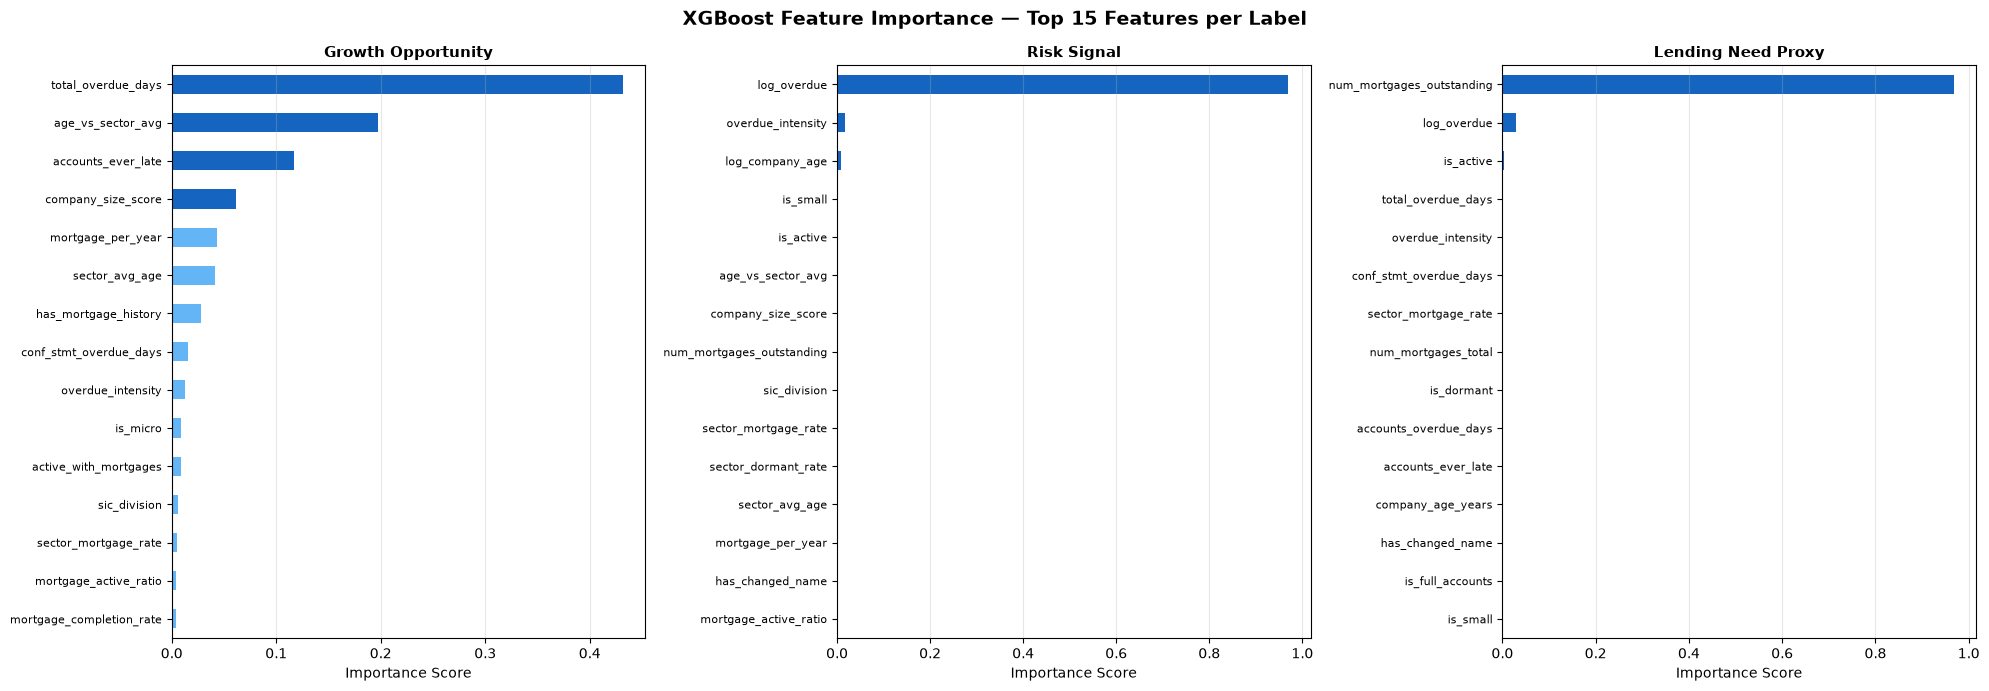

Saved: output/feature_importance.png
Saved: output/feature_importance_{growth,risk,lending}.csv

SECTOR BREAKDOWN — Companies with growth_prob > 0.8
bcb_sector
Technology_Legal_Professional        493349
Wholesale_Retail                     389703
Real_Estate                          344173
Healthcare                           103282
Manufacturing                         83031
Public_Sector_Education_Charities     72767
Agriculture                           18380


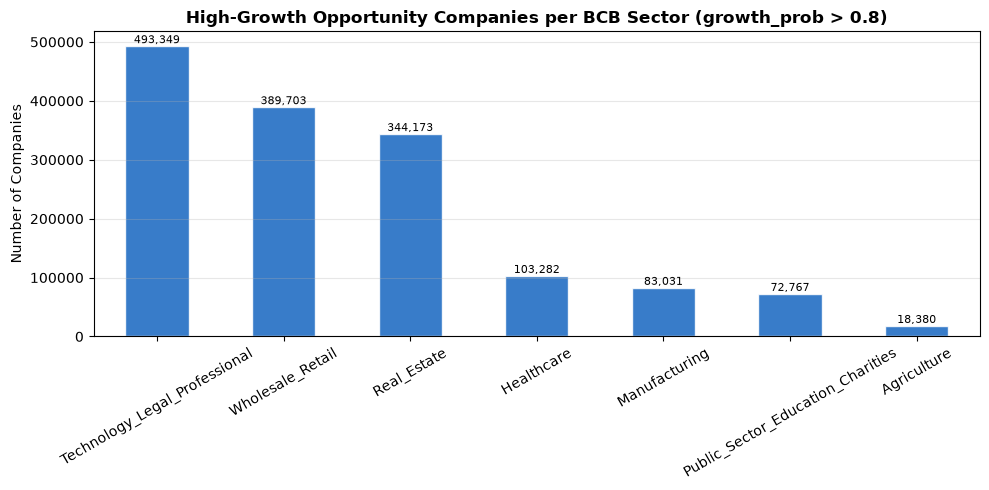


Saved: output/sector_opportunity_chart.png
Saved: output/sector_opportunity_count.csv


In [17]:
# ── EVALUATION CELL 3: FEATURE IMPORTANCE + SECTOR BREAKDOWN ──────────────

print("XGBoost FEATURE IMPORTANCE — Top 15 Features per Label")
print("="*60)

label_feat_config = [
    ('growth',  'Growth Opportunity',  GROWTH_FEATURES,  growth_models['XGBoost']),
    ('risk',    'Risk Signal',         RISK_FEATURES,    risk_models['XGBoost']),
    ('lending', 'Lending Need Proxy',  LENDING_FEATURES, lending_models['XGBoost']),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('XGBoost Feature Importance — Top 15 Features per Label', fontsize=14, fontweight='bold')

for idx, (label, title, features, model) in enumerate(label_feat_config):
    ax = axes[idx]
    feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True).tail(15)
    colors_fi = ['#1565C0' if v >= feat_imp.quantile(0.75) else '#64B5F6' for v in feat_imp.values]
    feat_imp.plot(kind='barh', ax=ax, color=colors_fi)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)
    # Save CSV
    pd.DataFrame({'feature': features, 'importance': model.feature_importances_})\
      .sort_values('importance', ascending=False)\
      .to_csv(f'output/feature_importance_{label}.csv', index=False)

plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/feature_importance.png")
print("Saved: output/feature_importance_{growth,risk,lending}.csv")

# ── Sector breakdown of ranked predictions ────────────────────────────────
print("\nSECTOR BREAKDOWN — Companies with growth_prob > 0.8")
print("="*60)

sector_counts = df_predictions[df_predictions['growth_prob'] > 0.8]\
    .groupby('bcb_sector').size().sort_values(ascending=False)
print(sector_counts.to_string())
sector_counts.reset_index().rename(columns={0:'count'})\
    .to_csv('output/sector_opportunity_count.csv', index=False)

# Plot sector breakdown
fig, ax = plt.subplots(figsize=(10, 5))
sector_counts.plot(kind='bar', ax=ax, color='#1565C0', alpha=0.85, edgecolor='white')
ax.set_title('High-Growth Opportunity Companies per BCB Sector (growth_prob > 0.8)', fontweight='bold')
ax.set_ylabel('Number of Companies')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('output/sector_opportunity_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: output/sector_opportunity_chart.png")
print("Saved: output/sector_opportunity_count.csv")